In [1]:
import sys
import os
from PyQt5.QtCore import QTimer, QDateTime, Qt, pyqtSignal
from PyQt5.QtGui import QFont, QImage, QPixmap
from PyQt5.QtWidgets import QApplication, QWidget, QLabel, QVBoxLayout, QHBoxLayout, QPushButton, QDialog, QFormLayout, QLineEdit, QRadioButton
import configparser
from pydicom.dataset import FileMetaDataset
from pydicom.uid import UID
from pydicom import Dataset
import pydicom

import cv2
import numpy as np
import sqlite3
import time
import random
from datetime import datetime

class PatientInfoDialog(QDialog):
    patient_info_signal = pyqtSignal(str, str, str, str, str)

    def __init__(self):
        super(PatientInfoDialog, self).__init__()

        self.setWindowTitle("Patient Information")
        self.setGeometry(100, 200, 300, 200)

        self.fbox = QFormLayout(self)

        self.name_label = QLabel("Name")
        self.name_edit = QLineEdit()
        self.fbox.addRow(self.name_label, self.name_edit)

        self.age_label = QLabel("Age")
        self.age_edit = QLineEdit()
        self.fbox.addRow(self.age_label, self.age_edit)

        self.sex_label = QLabel("Sex")
        self.sex_hbox = QHBoxLayout()
        self.male_radio = QRadioButton("Male")
        self.female_radio = QRadioButton("Female")
        self.sex_hbox.addWidget(self.male_radio)
        self.sex_hbox.addWidget(self.female_radio)
        self.fbox.addRow(self.sex_label, self.sex_hbox)

        self.physician_label = QLabel("Physician")
        self.physician_edit = QLineEdit()
        self.fbox.addRow(self.physician_label, self.physician_edit)

        self.comments_label = QLabel("Comments")
        self.comments_edit = QLineEdit()
        self.fbox.addRow(self.comments_label, self.comments_edit)

        submit_button = QPushButton("Submit")
        submit_button.clicked.connect(self.accept)
        cancel_button = QPushButton("Cancel")
        cancel_button.clicked.connect(self.reject)
        self.fbox.addRow(submit_button, cancel_button)

    def accept(self):
        # 发送信号，传递患者信息
        name = self.name_edit.text()
        sex = "Male" if self.male_radio.isChecked() else "Female"
        age = self.age_edit.text()
        physician = self.physician_edit.text()
        comments = self.comments_edit.text()
        self.patient_info_signal.emit(name, sex, age, physician, comments)
        super().accept()





In [2]:
class MainUI(QWidget):
    def __init__(self):
        super(MainUI, self).__init__()
        self.ImaNum = 0
        self.setGeometry(100, 200, 800, 800)
        self.setWindowTitle('PyQt5')
        self.setStyleSheet("background-color: black;")

        layout = QVBoxLayout(self)
        layout.setAlignment(Qt.AlignTop)

        font = QFont()
        font.setFamily("Arial")
        font.setPointSize(25)

        margin = 100

        self.name_label = QLabel("<a href='#'>Name: XXX</a>", self)
        self.name_label.setStyleSheet("color: white;")
        self.name_label.setFont(font)
        self.name_label.setMargin(margin)
        self.name_label.linkActivated.connect(self.show_patient_info_dialog)

        self.gender_label = QLabel("Sex: M\nAge: 41", self)
        self.gender_label.setStyleSheet("color: white;")
        self.gender_label.setFont(font)
        self.gender_label.setMargin(margin)

        self.datetime_label = QLabel()
        self.datetime_label.setStyleSheet("color: white;")
        self.datetime_label.setFont(font)
        self.datetime_label.setMargin(margin)

        self.physician_label = QLabel("PHY:\nCMT:", self)
        self.physician_label.setStyleSheet("color: white;")
        self.physician_label.setFont(font)
        self.physician_label.setMargin(margin)

        self.comments_label = QLabel("", self)
        self.comments_label.setStyleSheet("color: white;")
        self.comments_label.setFont(font)
        self.comments_label.setMargin(margin)
        
        lbl_Image = QLabel(self)
        self.image_label = lbl_Image

        left_layout = QVBoxLayout()
        left_layout.addWidget(self.name_label)
        left_layout.addWidget(self.gender_label)
        left_layout.addWidget(self.datetime_label)
        left_layout.addWidget(self.physician_label)
        left_layout.addWidget(self.comments_label)

        right_layout = QHBoxLayout()
        right_layout.addStretch(1)
        right_layout.addWidget(lbl_Image)

        combined_layout = QHBoxLayout(self)
        combined_layout.addLayout(left_layout)
        combined_layout.addLayout(right_layout)

        layout.addLayout(combined_layout)

        timer_datetime = QTimer(self)
        timer_datetime.timeout.connect(self.update_datetime)
        timer_datetime.start(1000)

        timer_image = QTimer(self)
        timer_image.timeout.connect(self.update_image)
        timer_image.start(int(1000 / 30))

        self.update_datetime()

        self.cap = cv2.VideoCapture(0)
        self.cap.set(3, 1280)
        self.cap.set(4, 720)

        self.config = configparser.ConfigParser()
        self.config.read('config.ini')
        self.mask_shape = self.config.get('SystemConfig', 'OverlayShape')
        self.image_storage_path = self.config.get('SystemConfig', 'ImageStoragePath')

        self.dialog = None
        self.image_sop_instance = {'Image': {'SOPInsUID': None}}
    

    def update_datetime(self):
        current_datetime = QDateTime.currentDateTime()
        date = current_datetime.toString('yyyy/MM/dd')
        time = current_datetime.toString('hh:mm:ss')
        self.datetime_label.setText(f"{date}\n{time}")

    def update_image(self):
        if self.image_label and self.cap.isOpened():
            ret, frame = self.cap.read()
            if ret:
                frame_rgbb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mask = self.create_mask(frame_rgbb.shape, self.mask_shape)
                frame_rgb = cv2.bitwise_and(frame_rgbb, frame_rgbb, mask=mask)
                height, width, channel = frame_rgb.shape
                bytes_per_line = 3 * width
                q_image = QImage(frame_rgb.data, width, height, bytes_per_line, QImage.Format_RGB888)
                pixmap = QPixmap.fromImage(q_image)
                self.image_label.setPixmap(pixmap)

    def create_mask(self, shape, mask_shape):
        if mask_shape == 'Circles':
            center = (shape[1] // 2, shape[0] // 2)
            radius = min(center)
            mask = np.zeros(shape[:2], dtype=np.uint8)
            cv2.circle(mask, center, radius, (255, 255, 255), -1)
        elif mask_shape == 'Squares':
            mask = np.ones(shape[:2], dtype=np.uint8) * 255
        elif mask_shape == 'Octagons':
            mask = np.zeros(shape[:2], dtype=np.uint8)
            center = (shape[1] // 2, shape[0] // 2)
            side_length = min(shape[1], shape[0]) // 2
            octagon_pts = self.generate_octagon(center, side_length)
            cv2.fillPoly(mask, [octagon_pts], 255)

        return mask

    def generate_octagon(self, center, side_length):
        angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
        octagon_pts = np.array(
            [(center[0] + int(np.cos(angle) * side_length), center[1] + int(np.sin(angle) * side_length))
             for angle in angles], dtype=np.int32)
        return octagon_pts

    def show_patient_info_dialog(self):
        image_sop_instance = {
            'Patient': {'PatNam': '', 'Sex': '', 'Age': ''},
            'Study': {'StuInsUID': '', 'OtherStudyInfo': ''},
            'Series': {'SerInsUID': '', 'OtherSeriesInfo': ''},
            'Image': {'SOPInsUID': '', 'StoragePath': ''}
        }

        success = self.openPatientInfoDialog(image_sop_instance)

        if success:
            self.updatePatientInfoUI(image_sop_instance)
            self.image_sop_instance = image_sop_instance
            self.captureAndSaveImage(self.image_sop_instance)

    def openPatientInfoDialog(self, image_sop_instance):
        self.dialog = PatientInfoDialog()

        def process_and_update(name, sex, age, physician, comments):
            self.processPatientInfo(name, sex, age, physician, comments, image_sop_instance)

            # Fill image_sop_instance with patient, Study, Series information
            image_sop_instance["Patient"] = {
                "PatNam": name,
                "PatBirDate": self.age_to_birthdate(int(age)),
                #TODO 字典的问题
                "PatSex": "M" if sex == "Male" else "F",
                "Sex": "M" if sex == "Male" else "F",
                "Age": int(age),
                "NumPatRelStu": 0,
                "NumPatRelSer": 0,
                "NumPatRelIma": 0
            }
            # TODO
            # image_sop_instance["Study"] ={
            #     "StuID": 1,
            #     "StuDate": datetime.now().strftime('%Y%m%d'),
            #     "StuTime": datetime.now().strftime('%H%M%S'),
            #     "AccNum": "1",
            #     "PatAge": age,
            #     "PatSize": 170,
            #     "PatWeight": 70,
            #     "NumStuRelSer": 0,
            #     "NumStuRelIma": 0,
            # }

            image_sop_instance["Study"].update({
                "StuID": 1,
                "StuDate": datetime.now().strftime('%Y%m%d'),
                "StuTime": datetime.now().strftime('%H%M%S'),
                "AccNum": "1",
                "PatAge": age,
                "PatSize": 170,
                "PatWeight": 70,
                "NumStuRelSer": 0,
                "NumStuRelIma": 0,
            })

            image_sop_instance["Series"].update({
                "SerNum": "1",
                "Modality": "ES",
                "ProNam": physician,
                "SerDes": comments,
                "BodParExa": "stomach",
                "NumSerRelIma": 0
            })

            # Generate unique IDs using the existing function generateUniqueID()
            image_sop_instance["Patient"]["PatID"] = self.generateUniqueID("2.25.", "PatID")
            image_sop_instance["Study"]["StuInsUID"] = self.generateUniqueID("2.25.", "StudyInsUID")
            image_sop_instance["Series"]["SerInsUID"] = self.generateUniqueID("2.25.", "SerInsUID")

            print(image_sop_instance)

        self.dialog.patient_info_signal.connect(process_and_update)
        result = self.dialog.exec_()

        return result == QDialog.Accepted
    
    def processPatientInfo(self, name, sex, age, physician, comments, image_sop_instance):
        prefix = "2.25."

        image_sop_instance['Patient']['PatID'] = self.generateUniqueID(prefix, "PatID")
        image_sop_instance['Study']['StuInsUID'] = self.generateUniqueID(prefix, "StudyInsUID")
        image_sop_instance['Series']['SerInsUID'] = self.generateUniqueID(prefix, "SerInsUID")

        image_sop_instance['Patient']['PatNam'] = name
        image_sop_instance['Patient']['Sex'] = sex
        image_sop_instance['Patient']['Age'] = age
        image_sop_instance['Study']['OtherStudyInfo'] = f"Physician: {physician}"
        image_sop_instance['Series']['OtherSeriesInfo'] = f"Comments: {comments}"

        self.updatePatientInfoUI(image_sop_instance)

    def captureAndSaveImage(self, image_sop_instance):
        ret,capturedImage = self.cap.read()
        if ret:
            self.ImaNum = self.ImaNum + 1 
        sopInsUID = self.generateUniqueID("2.25.", "ImageSOPInsUID")
        self.image_sop_instance.setdefault('Image', {})['SOPInsUID'] = sopInsUID
        self.image_sop_instance.setdefault('Image', {})['ImaNum'] = self.ImaNum
        self.image_sop_instance.setdefault('Image', {})['SOPClaUID'] = pydicom.uid.SecondaryCaptureImageStorage
        self.image_sop_instance.setdefault('Image', {})['TransferSyntax'] = pydicom.uid.ExplicitVRLittleEndian

        storagePath = "D:\\Che Qiancao\\sjtu\\课程\\7大四上\\课程设计\\project2\\" + sopInsUID + ".dcm"
        dicomImage = self.encodeToDICOM(image_sop_instance, capturedImage)
        self.saveDICOMImage(dicomImage, storagePath)
        image_sop_instance['Image']['StoragePath'] = storagePath
        self.updateDatabaseWithImageInfo(image_sop_instance)
        
    def encodeToDICOM(self, image_sop_instance, capturedImage):
        dicom_file = Dataset()
        file_meta = FileMetaDataset()
        file_meta.MediaStorageSOPClassUID = pydicom.uid.SecondaryCaptureImageStorage
        file_meta.MediaStorageSOPInstanceUID = image_sop_instance['Image']['SOPInsUID']
        file_meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian

        dicom_file.file_meta = file_meta
        dicom_file.is_little_endian = True
        dicom_file.is_implicit_VR = False

        dicom_file.PatientName = image_sop_instance['Patient']['PatNam']
        dicom_file.PatientID = image_sop_instance['Patient']['PatID']
        dicom_file.PatientBirthDate = image_sop_instance['Patient']['PatBirDate']
        dicom_file.PatientSex = image_sop_instance['Patient']['PatSex']

        dicom_file.StudyID = str(image_sop_instance['Study']['StuID'])
        dicom_file.StudyInstanceUID = image_sop_instance['Study']['StuInsUID']
        dicom_file.StudyDate = image_sop_instance['Study']['StuDate']
        dicom_file.StudyTime = image_sop_instance['Study']['StuTime']
        dicom_file.AccessionNumber = str(image_sop_instance['Study']['AccNum'])
        dicom_file.PatientAge = str(image_sop_instance['Study']['PatAge'])
        dicom_file.PatientSize = float(image_sop_instance['Study']['PatSize'])
        dicom_file.PatientWeight = float(image_sop_instance['Study']['PatWeight'])

        dicom_file.SeriesNumber = str(image_sop_instance['Series']['SerNum'])
        dicom_file.SeriesInstanceUID = image_sop_instance['Series']['SerInsUID']
        dicom_file.Modality = image_sop_instance['Series']['Modality']
        dicom_file.ProtocolName = image_sop_instance['Series']['ProNam']
        dicom_file.SeriesDescription = image_sop_instance['Series']['SerDes']
        dicom_file.BodyPartExamined = image_sop_instance['Series']['BodParExa']

        dicom_file.InstanceNumber = str(image_sop_instance['Image']['ImaNum'])
        dicom_file.SOPInstanceUID = image_sop_instance['Image']['SOPInsUID']
        dicom_file.ImageType = "DERIVED\\SECONDARY"

        dicom_file.Rows, dicom_file.Columns = capturedImage.shape[:2]
        dicom_file.PixelRepresentation = 0
        dicom_file.SamplesPerPixel = 3
        dicom_file.PhotometricInterpretation = "RGB"
        dicom_file.PlanarConfiguration = 0

        dicom_file.BitsAllocated = 8
        dicom_file.BitsStored = 8
        dicom_file.HighBit = 7

        dicom_file.PixelData = convert_image_to_dicom_format(capturedImage)

        return dicom_file

    def saveDICOMImage(self, dicomObject, storagePath):
        with open(storagePath, 'wb') as file:
            dicomObject.save_as(file)

    def updateDatabaseWithImageInfo(self, image_sop_instance):
        conn = sqlite3.connect('pcas2023.db')  # Replace with your actual database filename
        cursor = conn.cursor()
        
        cursor.execute("SELECT * FROM PatientLevel WHERE PatID = ?", (image_sop_instance['Patient']['PatID'],))
        if cursor.fetchone() is None:  #如果患者（Patient）不存在于数据库
            cursor.execute("""
                INSERT INTO PatientLevel(PatID, PatNam, PatBirDate, PatSex)
                VALUES (?, ?, ?, ?)
            """, (image_sop_instance['Patient']['PatID'], image_sop_instance['Patient']['PatNam'], 
                  image_sop_instance['Patient']['PatBirDate'], image_sop_instance['Patient']['PatSex']))
            
            # 检查并插入检查信息
        cursor.execute("SELECT * FROM StudyLevel WHERE StuInsUID = ?", (image_sop_instance['Study']['StuInsUID'],))
        if cursor.fetchone() is None: #如果检查(Study)不存在于数据库
            cursor.execute("""
                INSERT INTO StudyLevel(StuInsUID, StuID, StuDate, StuTime, AccNum, PatAge, PatSize, PatWeight, PatID)
                VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
            """, (image_sop_instance['Study']['StuInsUID'], image_sop_instance['Study']['StuID'], 
                  image_sop_instance['Study']['StuDate'], image_sop_instance['Study']['StuTime'], 
                  image_sop_instance['Study']['AccNum'], image_sop_instance['Study']['PatAge'], 
                  image_sop_instance['Study']['PatSize'], image_sop_instance['Study']['PatWeight'], 
                  image_sop_instance['Patient']['PatID']))

    # 检查并插入序列信息 
        cursor.execute("SELECT * FROM SeriesLevel WHERE SerInsUID = ?", (image_sop_instance['Series']['SerInsUID'],))
        if cursor.fetchone() is None: #如果序列（Series）不存在于数据库
            cursor.execute("""
                INSERT INTO SeriesLevel(SerInsUID, SerNum, Modality, ProNam, SerDes, BodParExa, StuInsUID)
                VALUES (?, ?, ?, ?, ?, ?, ?)
            """, (image_sop_instance['Series']['SerInsUID'], image_sop_instance['Series']['SerNum'], 
                  image_sop_instance['Series']['Modality'], image_sop_instance['Series']['ProNam'], 
                  image_sop_instance['Series']['SerDes'], image_sop_instance['Series']['BodParExa'], 
                  image_sop_instance['Study']['StuInsUID']))

    # 检查并插入图像信息
        cursor.execute("SELECT * FROM ImageLevel WHERE SOPInsUID = ?", (image_sop_instance['Image']['SOPInsUID'],))
        if cursor.fetchone() is None: #如果图像（Image）不存在于数据库
            cursor.execute("""
                INSERT INTO ImageLevel(SOPInsUID, ImaNum, SOPClaUID, TransferSyntax, StoragePath, SerInsUID)
                VALUES (?, ?, ?, ?, ?, ?)
            """, (image_sop_instance['Image']['SOPInsUID'], image_sop_instance['Image']['ImaNum'], 
                  image_sop_instance['Image']['SOPClaUID'], image_sop_instance['Image']['TransferSyntax'], 
                  image_sop_instance['Image']['StoragePath'], image_sop_instance['Series']['SerInsUID']))


        conn.commit()
        conn.close()

    def updatePatientInfoUI(self, image_sop_instance):
        self.name_label.setText(f"<a href='#'>Name: {image_sop_instance['Patient']['PatNam']}</a>")
        gender_and_age = f"Sex: {image_sop_instance['Patient']['Sex']}\nAge: {image_sop_instance['Patient']['Age']}"
        self.gender_label.setText(gender_and_age)

        physician_label_text = f"PHY: {image_sop_instance['Study']['OtherStudyInfo'].split(':')[1]}\nCMT: {image_sop_instance['Series']['OtherSeriesInfo'].split(': ')[1]}"
        self.physician_label.setText(physician_label_text)
        self.comments_label.setText(f"Comments: {image_sop_instance['Series']['OtherSeriesInfo'].split(': ')[1]}")

    def generateUniqueID(self, prefix, type):
        typeStr = ""
        if type == "PatID":
            typeStr = "1."
        elif type == "StudyInsUID":
            typeStr = "2."
        elif type == "SerInsUID":
            typeStr = "3."
        elif type == "ImageSOPInsUID":
            typeStr = "4."

        randomPart = str(int(time.time())) + str(random.randint(1, 9999))

        uid = prefix + typeStr + randomPart
        return uid
    # TODO: self arguments
    def age_to_birthdate(self, age):
        try:
            birth_year = datetime.now().year - int(age)
            return f"{birth_year}-1-1"
        except ValueError:
            return "2000-1-1"


In [3]:
def convert_image_to_dicom_format(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.reshape(-1, 3)
    image = image.flatten('C')
    return image.tobytes()

In [4]:
if __name__ == '__main__':
    app = QApplication(sys.argv)
    main_window = MainUI()
    main_window.show()
    sys.exit(app.exec_())

{'Patient': {'PatNam': 'qqy', 'PatBirDate': '2003-1-1', 'PatSex': 'F', 'Sex': 'F', 'Age': 21, 'NumPatRelStu': 0, 'NumPatRelSer': 0, 'NumPatRelIma': 0, 'PatID': '2.25.1.17048768814169'}, 'Study': {'StuInsUID': '2.25.2.17048768818285', 'OtherStudyInfo': 'Physician: abcdef', 'StuID': 1, 'StuDate': '20240110', 'StuTime': '165441', 'AccNum': '1', 'PatAge': '21', 'PatSize': 170, 'PatWeight': 70, 'NumStuRelSer': 0, 'NumStuRelIma': 0}, 'Series': {'SerInsUID': '2.25.3.17048768819520', 'OtherSeriesInfo': 'Comments: abcdef', 'SerNum': '1', 'Modality': 'ES', 'ProNam': 'abcdef', 'SerDes': 'abcdef', 'BodParExa': 'stomach', 'NumSerRelIma': 0}, 'Image': {'SOPInsUID': '', 'StoragePath': ''}}


D:\Program_D\anaconda3\lib\site-packages\pydicom\valuerep.py:290: UserWarning: Invalid value for VR DA: '2003-1-1'.
  warnings.warn(msg)
D:\Program_D\anaconda3\lib\site-packages\pydicom\valuerep.py:290: UserWarning: Invalid value for VR AS: '21'.
  warnings.warn(msg)
D:\Program_D\anaconda3\lib\site-packages\pydicom\valuerep.py:290: UserWarning: Invalid value for VR CS: 'stomach'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)


SystemExit: 0

D:\Program_D\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3406: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


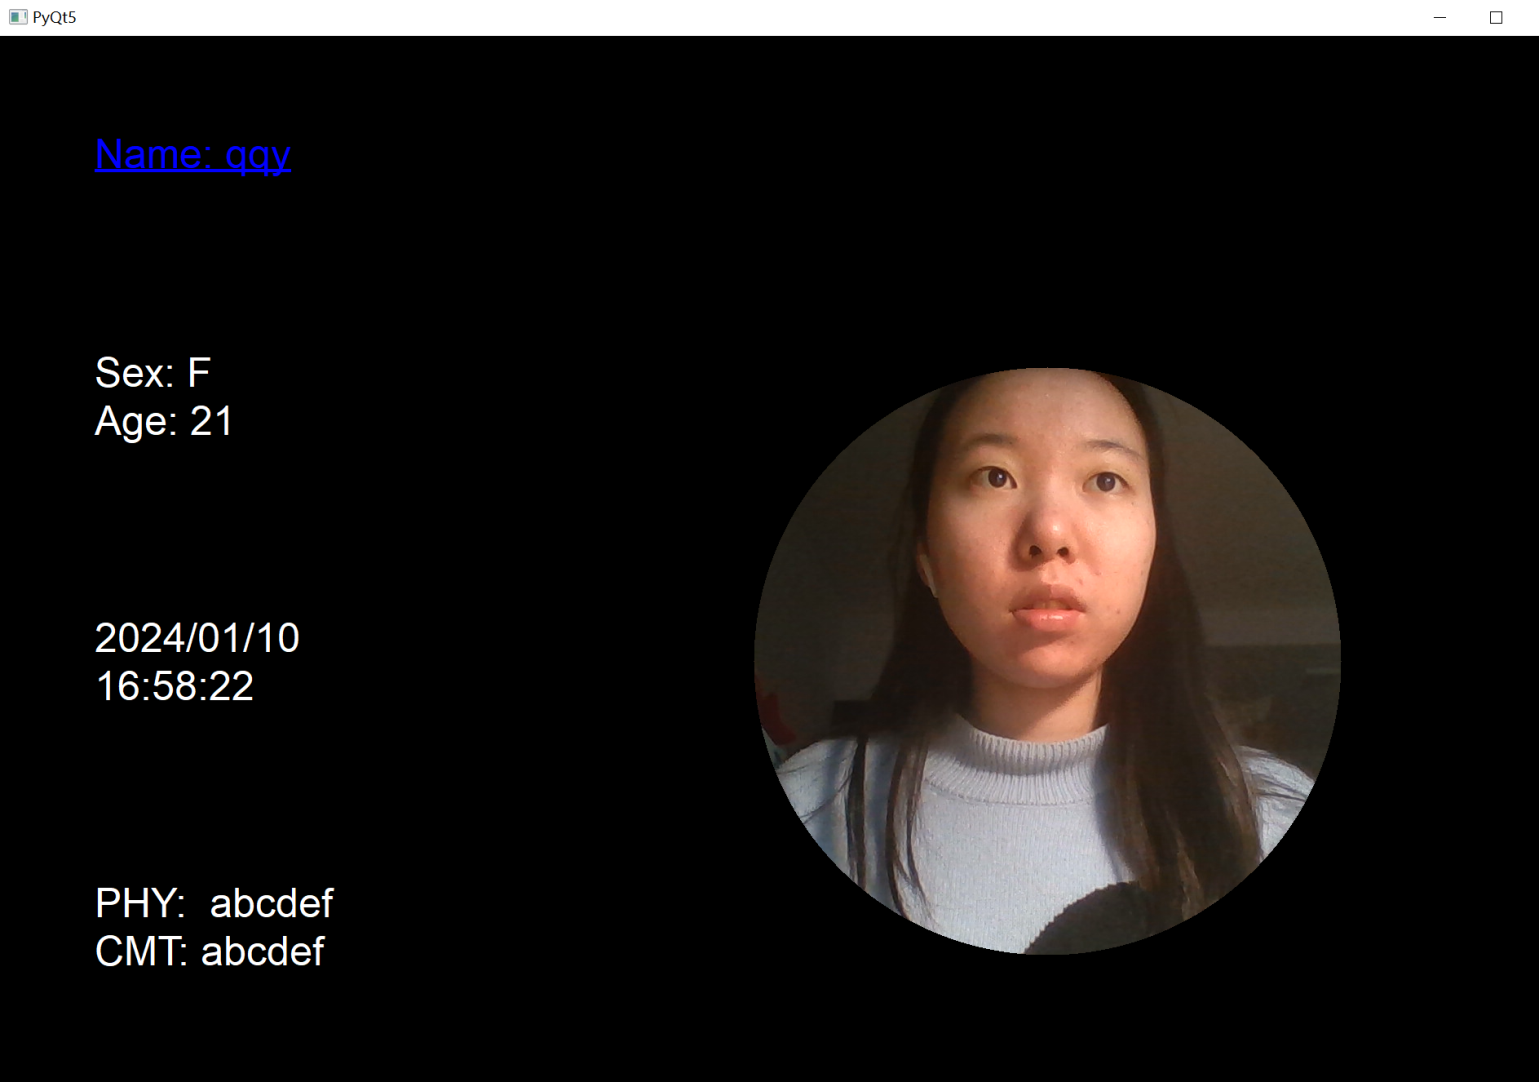